📊 Customer Churn Prediction Using Logistic Regression



# 1. Business Understanding

## Project Overview

Customer churn is one of the biggest challenges in the retail industry because retaining existing customers is generally more cost-effective than acquiring new ones.

This project aims to analyze customer transaction behavior and build a Logistic Regression model to predict whether a customer is likely to churn. The analysis also provides business insights and recommendations to support customer retention strategies.

---

## Objectives

- Analyze customer transaction behavior.
- Identify churn patterns.
- Build a predictive churn model.
- Evaluate model performance.
- Generate business recommendations.

---

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

---

## Dataset

Retail Customer Transaction Dataset (DQLab)


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

plt.style.use('ggplot')

# Data Understanding

The dataset contains customer transaction records including transaction dates, products purchased, transaction amounts, and purchase frequency.

Before building the machine learning model, we first inspect the dataset structure and data quality.

In [23]:
url = "https://dqlabcdn.xeratic.com/dqlab-dataset/data_retail.csv"

df = pd.read_csv(url, sep=';')

df.head()

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   no                          100000 non-null  int64 
 1   Row_Num                     100000 non-null  int64 
 2   Customer_ID                 100000 non-null  int64 
 3   Product                     100000 non-null  object
 4   First_Transaction           100000 non-null  int64 
 5   Last_Transaction            100000 non-null  int64 
 6   Average_Transaction_Amount  100000 non-null  int64 
 7   Count_Transaction           100000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 6.1+ MB


,0
no,0
Row_Num,0
Customer_ID,0
Product,0
First_Transaction,0
Last_Transaction,0
Average_Transaction_Amount,0
Count_Transaction,0


# Data Preparation

In this stage, transaction timestamps are converted into datetime format to enable feature engineering and temporal analysis.

Additional features are created to improve the predictive capability of the machine learning model.

In [3]:
df['First_Transaction'] = pd.to_datetime(
    df['First_Transaction']/1000,
    unit='s',
    origin='1970-01-01'
)

df['Last_Transaction'] = pd.to_datetime(
    df['Last_Transaction']/1000,
    unit='s',
    origin='1970-01-01'
)

# Feature Engineering

New features are created from transaction dates to capture customer purchasing history.

The churn label is also generated based on the last transaction date.

In [4]:
df['Year_First_Transaction'] = df['First_Transaction'].dt.year
df['Year_Last_Transaction'] = df['Last_Transaction'].dt.year

In [5]:
df['is_churn'] = np.where(
    df['Last_Transaction'] <= '2018-08-01',
    True,
    False
)

df.head()

,no,Row_Num,Customer_ID,Product,First_Transaction,Last_Transaction,Average_Transaction_Amount,Count_Transaction,Year_First_Transaction,Year_Last_Transaction,is_churn
0,1,1,29531,Jaket,2016-06-19 02:44:34.395999908,2018-10-05 05:48:02.608000040,1467681,22,2016,2018,False
1,2,2,29531,Sepatu,2014-07-23 01:02:11.493999958,2018-12-25 11:02:41.269999981,1269337,41,2014,2018,False
2,3,3,141526,Tas,2017-04-28 03:12:27.000000000,2019-01-24 09:40:02.000000000,310915,30,2017,2019,False
3,4,4,141526,Jaket,2017-04-28 06:52:52.546999931,2019-01-16 13:00:03.911000013,722632,27,2017,2019,False
4,5,5,37545,Sepatu,2015-04-16 10:01:38.530999899,2018-11-22 12:53:41.529999970,1775036,25,2015,2018,False


# Exploratory Data Analysis

EDA is performed to understand customer behavior and identify potential patterns related to customer churn.

# Customer Acquisition

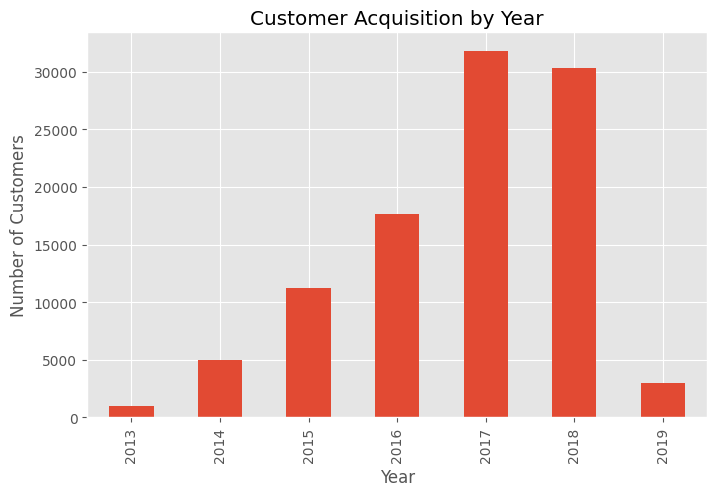

In [6]:
customer_year = (
    df.groupby("Year_First_Transaction")["Customer_ID"]
      .count()
)

plt.figure(figsize=(8,5))

customer_year.plot(kind="bar")

plt.title("Customer Acquisition by Year")
plt.xlabel("Year")
plt.ylabel("Number of Customers")

plt.show()

### Insight

Customer acquisition increased significantly until 2017 before declining in subsequent years. This trend indicates that customer growth slowed after reaching its peak, suggesting the need for improved acquisition strategies to attract new customers.

# Transaction by Year

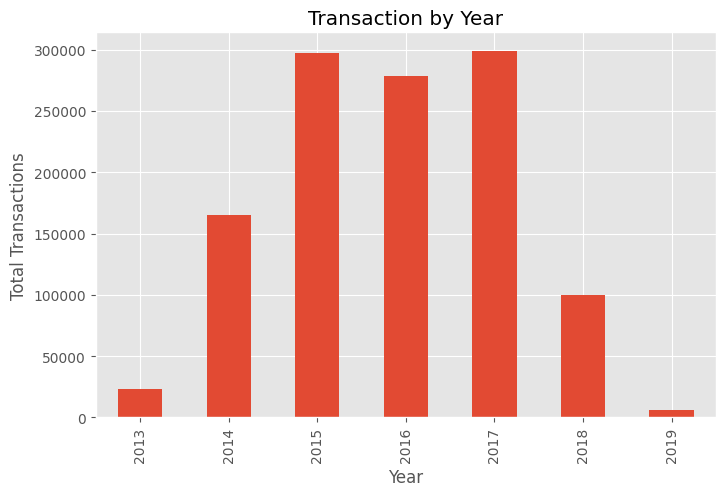

In [7]:
transaction_year = (
    df.groupby("Year_First_Transaction")["Count_Transaction"]
      .sum()
)

plt.figure(figsize=(8,5))

transaction_year.plot(kind="bar")

plt.title("Transaction by Year")
plt.xlabel("Year")
plt.ylabel("Total Transactions")

plt.show()

### Insight

The total number of transactions generally followed the customer acquisition trend. Years with more newly acquired customers also recorded higher transaction volumes, indicating a positive relationship between customer growth and purchasing activity.

# Average Transaction Amount

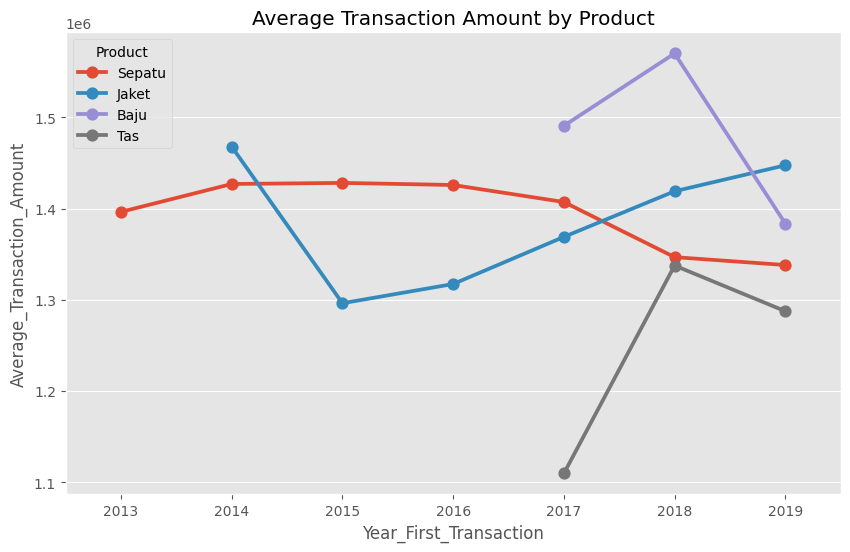

In [8]:
avg_transaction = (
    df.groupby(["Year_First_Transaction","Product"])
    ["Average_Transaction_Amount"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.pointplot(
    data=avg_transaction,
    x="Year_First_Transaction",
    y="Average_Transaction_Amount",
    hue="Product"
)

plt.title("Average Transaction Amount by Product")

plt.show()

### Insight

Average transaction values vary across product categories and years, suggesting differences in customer purchasing behavior. Certain products consistently generate higher transaction values, making them potential contributors to overall revenue growth.

# Churn Proportion by Product

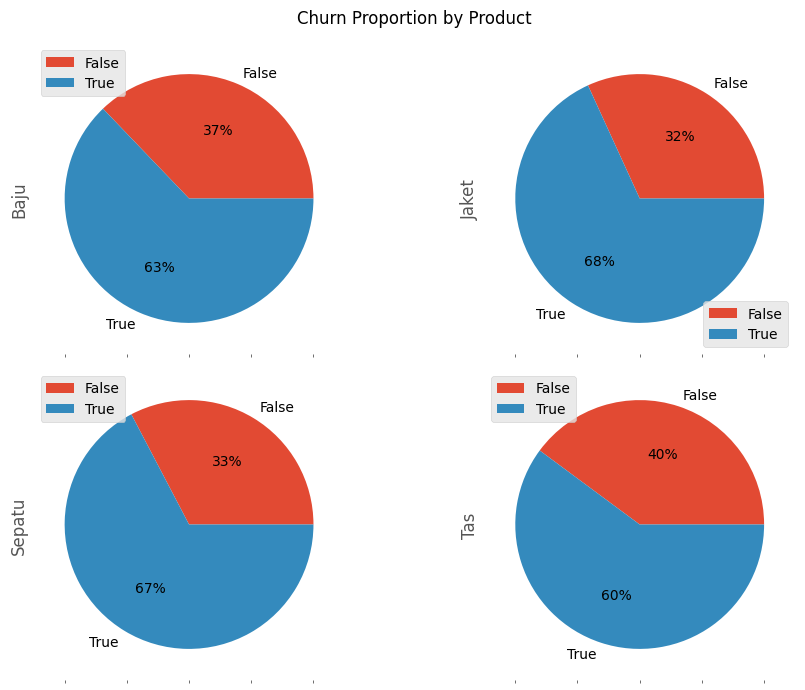

In [9]:
pivot = pd.pivot_table(
    df,
    index="is_churn",
    columns="Product",
    values="Customer_ID",
    aggfunc="count",
    fill_value=0
)

pivot.plot(
    kind="pie",
    subplots=True,
    figsize=(10,7),
    autopct="%1.0f%%",
    layout=(2,2),
    title="Churn Proportion by Product"
)

plt.tight_layout()

plt.show()

# Insight

The proportion of churn customers differs across product categories. Some products have a higher percentage of churn customers, indicating that targeted retention strategies may be required for those specific product segments.

# Distribution of Transaction Count

In [10]:
def transaction_group(row):

    if row["Count_Transaction"] == 1:
        return "1"

    elif row["Count_Transaction"] <= 3:
        return "2-3"

    elif row["Count_Transaction"] <= 6:
        return "4-6"

    elif row["Count_Transaction"] <= 10:
        return "7-10"

    else:
        return ">10"

df["Count_Transaction_Group"] = df.apply(transaction_group, axis=1)

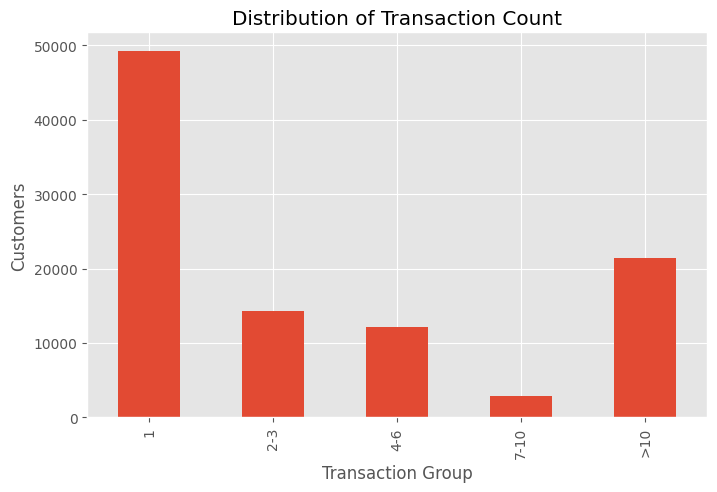

In [11]:
count_group = (
    df.groupby("Count_Transaction_Group")["Customer_ID"]
    .count()
)

count_group = count_group.reindex(
    ["1","2-3","4-6","7-10",">10"]
)

plt.figure(figsize=(8,5))

count_group.plot(kind="bar")

plt.title("Distribution of Transaction Count")

plt.xlabel("Transaction Group")

plt.ylabel("Customers")

plt.show()

# Insight

Most customers belong to the lower transaction frequency groups, while only a small proportion of customers make frequent purchases. Customers with fewer transactions may be more likely to churn, highlighting the importance of increasing customer engagement.

# Distribution of Average Transaction Amount

In [12]:
def amount_group(row):

    amount = row["Average_Transaction_Amount"]

    if amount <= 250000:
        return "100K-250K"

    elif amount <= 500000:
        return "250K-500K"

    elif amount <= 750000:
        return "500K-750K"

    elif amount <= 1000000:
        return "750K-1M"

    elif amount <= 2500000:
        return "1M-2.5M"

    elif amount <= 5000000:
        return "2.5M-5M"

    elif amount <= 10000000:
        return "5M-10M"

    else:
        return ">10M"

df["Average_Transaction_Group"] = df.apply(amount_group, axis=1)

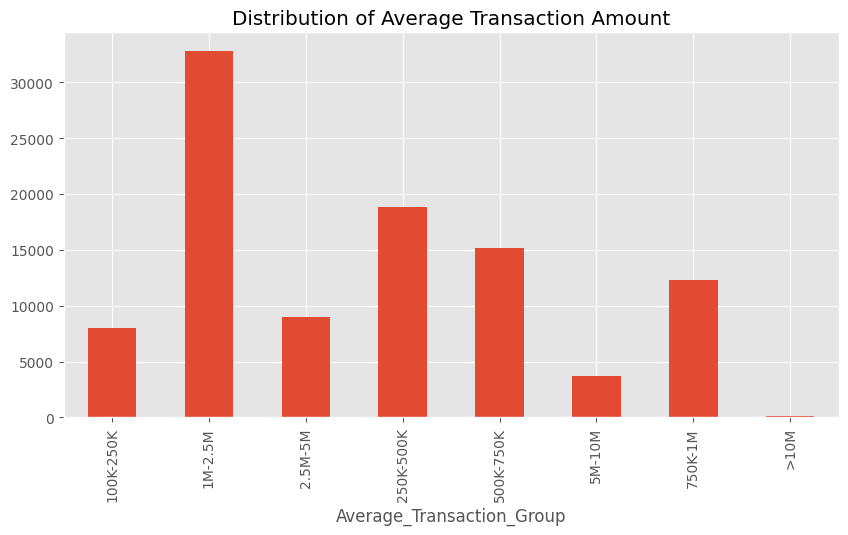

In [13]:
amount_dist = (
    df.groupby("Average_Transaction_Group")["Customer_ID"]
    .count()
)

plt.figure(figsize=(10,5))

amount_dist.plot(kind="bar")

plt.title("Distribution of Average Transaction Amount")

plt.show()

# Insight
Most customers fall within the lower average transaction amount groups, while high-spending customers represent a relatively small segment. Maintaining relationships with high-value customers is important because they contribute significantly to business revenue.

# Machine Learning

After exploring customer behavior, a Logistic Regression model is developed to predict customer churn using selected customer transaction features.

# Model Evaluation (Confusion Matrix)





In [14]:
df["Year_Diff"] = (
    df["Year_Last_Transaction"] -
    df["Year_First_Transaction"]
)

In [15]:
feature_columns = [
    "Average_Transaction_Amount",
    "Count_Transaction",
    "Year_Diff"
]

X = df[feature_columns]

y = df["is_churn"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [17]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

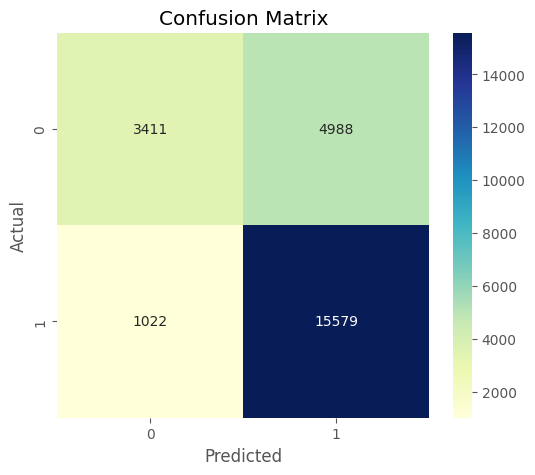

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Interpretation

The Logistic Regression model successfully classified the majority of customers with good overall performance. However, several churn customers were still misclassified, indicating that additional predictive features or more advanced machine learning models could further improve performance.

# Model Evaluation (Accuracy, Precision, Recall)

In [19]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))

Accuracy : 0.7596
Precision: 0.7574755676569261
Recall   : 0.9384374435274984


#Interpretation

The evaluation metrics indicate that the model provides a reliable baseline for predicting customer churn. Accuracy measures overall prediction performance, while Precision and Recall evaluate the model's ability to correctly identify churn customers.

# Model Evaluation (Classification Report)

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.77      0.41      0.53      8399
        True       0.76      0.94      0.84     16601

    accuracy                           0.76     25000
   macro avg       0.76      0.67      0.68     25000
weighted avg       0.76      0.76      0.74     25000



# Interpretation

The classification report provides a comprehensive evaluation of the model by summarizing Precision, Recall, F1-score, and Support for each class. These metrics help assess the model's effectiveness in distinguishing churn and non-churn customers.

# Feature Importance

In [21]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": model.coef_[0]
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
0,Average_Transaction_Amount,-6.669768e-09
1,Count_Transaction,-2.692919e-02
2,Year_Diff,-5.074687e-01


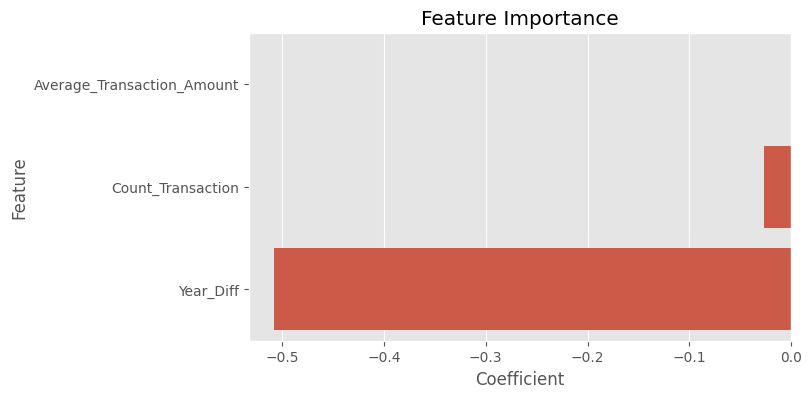

In [22]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

### Interpretation

The feature importance analysis shows that **Year_Diff** is the most influential predictor in the Logistic Regression model. This indicates that the length of a customer's transaction history plays a significant role in determining churn behavior.

In contrast, **Count_Transaction** has a relatively smaller effect, while **Average_Transaction_Amount** contributes minimally to the prediction. These results suggest that customer retention is more closely associated with purchasing history than with spending amount.

# Business Recommendations

Based on the analysis, several strategies can be implemented to reduce customer churn:
*   Develop personalized promotional campaigns for customers with declining transaction activity.
*   Introduce loyalty and reward programs to encourage repeat purchases.
*   Focus retention efforts on customers with low transaction frequency, as they are more likely to churn.
*   Monitor high-value customers and provide exclusive offers to maintain long-term customer relationships.





# ✅ Conclusion

This project demonstrates how customer transaction data can be transformed into actionable business insights using Exploratory Data Analysis (EDA) and Machine Learning. The Logistic Regression model provides a baseline approach for predicting customer churn and can support customer retention strategies. Future improvements may include feature enhancement and the evaluation of more advanced machine learning algorithms to improve predictive performance.